In [1]:
import pandas as pd
import numpy as np


In [28]:
class SimpleGD:
    
    def __init__(self,learning_rate = 0.0001 , epochs = 100):
        self.m = 0
        self.b = 0
        self.learning_rate = learning_rate
        self.epochs = epochs  
        
    def fit(self, X , y):
        X = np.asarray(X).ravel()
        y = np.asarray(y).ravel()
        
        for i in range(self.epochs):
            loss_slope = -2 * np.sum((y - self.m*X - self.b)*X)
            loss_intercept = -2 * np.sum(y-self.m*X - self.b)
            
            self.b = self.b - self.learning_rate * loss_intercept
            self.m = self.m - self.learning_rate * loss_slope
        
    def predict(self, X):
        return self.m * X + self.b

In [29]:
X = np.random.randint(1, 100, 100)
y = 5 * X + 3 + np.random.normal(0, 10, 100)

df = pd.DataFrame({
    "X": X,
    "y": y
})

df.head()

,X,y
0,77,404.524964
1,46,252.568898
2,7,33.430721
3,6,41.799031
4,87,441.039937


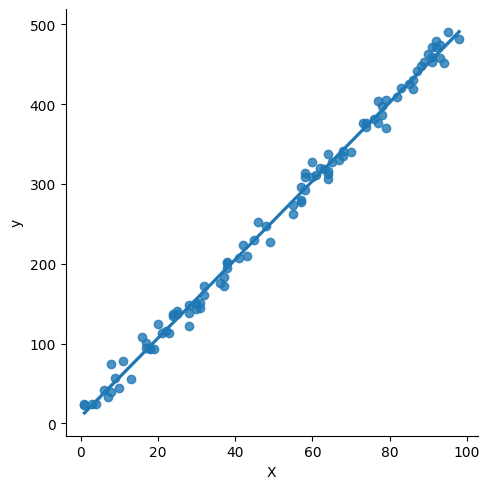

In [35]:
import seaborn as sns
sns.lmplot(data = df , x = "X" ,y= "y")

In [30]:
from sklearn.model_selection import train_test_split
X_train , X_test ,y_train ,y_test = train_test_split(df[['X']] , df[['y']] , test_size = 0.2)

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
gd = SimpleGD(learning_rate = 0.0001 , epochs = 1000)
gd.fit(X_train, y_train)
y_pred = gd.predict(X_test)
print(gd.m , gd.b)
from sklearn.metrics import r2_score
print(r2_score(y_test ,y_pred))

133.41314706298013 241.04244327706243
0.9945774689745519


## Using scikit learn

In [40]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train ,y_train)
y_pred = lr.predict(X_test)
print(r2_score(y_test ,y_pred))


0.994577473984556
